# M2 Deep Learning Coursework

Harvey Bermingham

In [29]:
#importing os
import os

#initialising a global seed
GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED) #setting Python's initialisation seed
os.environ['CUDA_VISIBLE_DEVICES'] = "-1" #avoiding use of any NVIDIA GPUs

#importing general packages
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

#manually setting PyTorch seeds
torch.manual_seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 0. Preprocessing and Data Exploration

Loading data from the CSV files.

In [30]:
# Load data
DATA_DIR = Path("data")
train_df = pd.read_csv(DATA_DIR / "moons_train.csv")
val_df = pd.read_csv(DATA_DIR / "moons_val.csv")
test_df = pd.read_csv(DATA_DIR / "moons_test.csv")


Exploring the layout of the datasets and defining their structure.

In [31]:
# Structure: shape, columns, dtypes
expected = {"train": 800, "val": 100, "test": 100}
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:<5s}  shape={str(df.shape):<10s}  columns={list(df.columns)}")
print("\ndtypes (all datasets identical):\n", train_df.dtypes)

train  shape=(800, 3)    columns=['x1', 'x2', 'class']
val    shape=(100, 3)    columns=['x1', 'x2', 'class']
test   shape=(100, 3)    columns=['x1', 'x2', 'class']

dtypes (all datasets identical):
 x1       float64
x2       float64
class      int64
dtype: object


**Missing values and duplicates**

In [32]:
# Missing values and duplicates
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    nan_x1 = df["x1"].isna().sum()
    nan_x2 = df["x2"].isna().sum()
    dup = df.duplicated(subset=["x1", "x2"]).sum()
    print(f"{name:<5s}  NaNs x1={nan_x1}  x2={nan_x2}  duplicates={dup}")

train  NaNs x1=0  x2=0  duplicates=0
val    NaNs x1=0  x2=0  duplicates=0
test   NaNs x1=0  x2=0  duplicates=0


No missing values or duplicates have been found in any of the provided datasets.

**Tensors and data as input**

In [33]:
x_train = torch.from_numpy(train_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_val = torch.from_numpy(val_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_test = torch.from_numpy(test_df[["x1", "x2"]].to_numpy(dtype=np.float32))
class_train = train_df["class"].values
class_val = val_df["class"].values
class_test = test_df["class"].values
print(f"Class balance (train):  class 0 ={int((class_train == 0).sum()):>4d}   class 1 ={int((class_train == 1).sum()):>4d}")
print()
for name, t in [("x_train", x_train), ("x_val", x_val), ("x_test", x_test)]:
    print(f"{name:<7s}  shape={str(tuple(t.shape)):<10s}  dtype={str(t.dtype):<14s}  min={t.min().item():>8.4f}  max={t.max().item():>8.4f}")

Class balance (train):  class 0 = 385   class 1 = 415

x_train  shape=(800, 2)    dtype=torch.float32   min= -1.1268  max=  2.0669
x_val    shape=(100, 2)    dtype=torch.float32   min= -1.0031  max=  2.0290
x_test   shape=(100, 2)    dtype=torch.float32   min= -1.0391  max=  2.0557


All three splits contain the expected sample counts (800 / 100 / 100) with columns x1, x2, and class. No missing values or duplicates appear in any split. The training set has a mild class imbalance (385 class 0 vs 415 class 1). Features span roughly [−1.13, 2.07] and are stored as float32 tensors. The pipeline uses raw feature values without scaling.

**Class Distributions** 

The following figures inspect class structure, spatial distribution of the features, and consistency across splits.

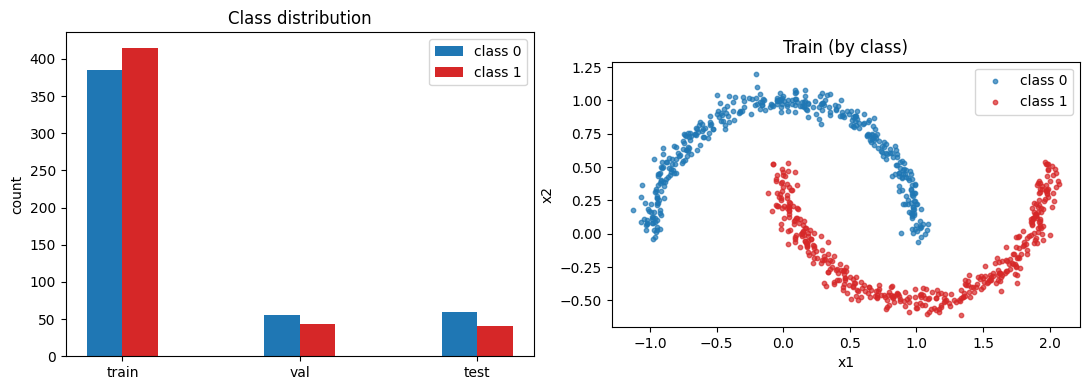

In [ ]:
# Figure 1: Class distribution + Train (by class) scatter
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
splits = [("train", train_df), ("val", val_df), ("test", test_df)]
cnt = np.array([[(df["class"] == 0).sum(), (df["class"] == 1).sum()] for _, df in splits])
x, w = np.arange(3), 0.2
axes[0].bar(x - w/2, cnt[:, 0], w, label="class 0", color="#1f77b4")
axes[0].bar(x + w/2, cnt[:, 1], w, label="class 1", color="#d62728")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["train", "val", "test"])
axes[0].set_ylabel("count")
axes[0].set_title("Class distribution")
axes[0].legend()
X = x_train.numpy()
axes[1].scatter(X[class_train == 0, 0], X[class_train == 0, 1], c="#1f77b4", label="class 0", alpha=0.7, s=10)
axes[1].scatter(X[class_train == 1, 0], X[class_train == 1, 1], c="#d62728", label="class 1", alpha=0.7, s=10)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Train (by class)")
axes[1].legend()
axes[1].set_aspect("equal")
plt.tight_layout()
fig.savefig("figs_my/class_and_train_scatter.png")
plt.show()

The Class distribution bar chart confirms the mild class imbalance in the training set. Validation and test splits each contain approximately 50 samples per class. The scatter plot shows the classes create two disctinct overlapping crescent shapes and a non-linearly separable.

**General Data Distribution and Density**

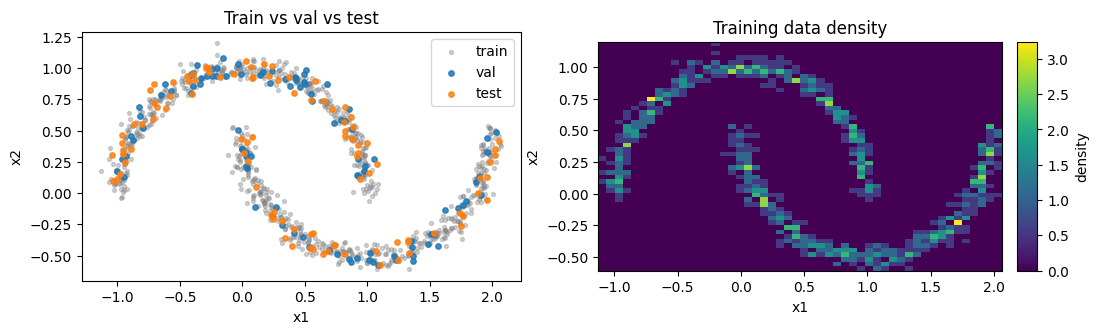

In [ ]:
# Figure 2: Train vs val vs test + Training density
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(x_train[:, 0], x_train[:, 1], c="gray", alpha=0.35, s=8, label="train")
axes[0].scatter(x_val[:, 0], x_val[:, 1], alpha=0.85, s=15, label="val")
axes[0].scatter(x_test[:, 0], x_test[:, 1], alpha=0.85, s=15, label="test")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Train vs val vs test")
axes[0].legend()
axes[0].set_aspect("equal")
xt, yt = x_train[:, 0].numpy(), x_train[:, 1].numpy()
H_2d, xe, ye = np.histogram2d(xt, yt, bins=50)
H_2d = H_2d / (H_2d.sum() * (xe[1] - xe[0]) * (ye[1] - ye[0]))
pc = axes[1].pcolormesh(xe, ye, H_2d.T, shading="auto", cmap="viridis")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Training data density")
axes[1].set_aspect("equal")
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(pc, cax=cax, label="density")
plt.tight_layout()
fig.savefig("figs_my/overlay_and_density.png")
plt.show()

The overlay plot shows train, validation, and test points occupying the same region of feature space with no visible distribution shift between splits. The density plot concentrates probability mass along the two crescents. Peak density reaches approximately 3.0, while the space between the crescents sits near zero. This thin, curved support structure provides a meaningful test for a normalising flow, which must map a simple base distribution onto the data manifold.

## 1. A Mini Normalising Flow

### 1) (a) 

Building affine coupling net in pytorch.

In [ ]:
# Single MLP: Linear(D→H) → ReLU → Linear(H→2D), then split into s and t. Spec: D=1 here.
class STNet(nn.Module):
    """Scale/shift network used inside a 2D affine coupling layer.

    Given the fixed dimension (shape (B, 1)), this MLP outputs coupling parameters
    
    (s, t)
    (each shape (B, 1)) for transforming the other dimension.

    Notes:
    - The scale output is bounded with `tanh` for numerical stability.
    """

    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, h_fixed):
        """Compute coupling parameters.

        Args:
            h_fixed: Tensor of shape (B, 1).

        Returns:
            s: Tensor of shape (B, 1), bounded via `tanh`.
            t: Tensor of shape (B, 1).
        """
        st = self.net(h_fixed)
        s, t = st.chunk(2, dim=-1)
        s = torch.tanh(s)
        return s, t


# Affine coupling: always fix dim 0 and transform dim 1.
class AffineCoupling2D(nn.Module):
    """RealNVP-style affine coupling transform for 2D vectors.

    Dimension 0 is kept fixed and dimension 1 is affine-transformed using parameters
    produced by `STNet`. The transform returns the output and the corresponding
    log-determinant of the Jacobian.
    """

    def __init__(self, hidden=64):
        super().__init__()
        self.st_net = STNet(hidden=hidden)

    def forward(self, z):
        """Forward map (base z -> data x).

        Args:
            z: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_f(z)|.
        """
        fixed, trans = z[:, :1], z[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, trans * scale + t], dim=-1)
        log_det = s.squeeze(-1)
        return out, log_det

    def inverse(self, x):
        """Inverse map (data x -> base z).

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            z: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_{f^{-1}}(x)|.
        """
        fixed, trans = x[:, :1], x[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, (trans - t) / scale], dim=-1)
        log_det = -s.squeeze(-1)
        return out, log_det

Now testing this flow.

Checking for shape:

In [37]:
layer = AffineCoupling2D(hidden=64)
z = torch.randn(10,2)
x, log_det_f = layer(z)
z_recon, log_det_inv = layer.inverse(x)

print(z.shape, x.shape, log_det_f.shape, log_det_inv.shape)

torch.Size([10, 2]) torch.Size([10, 2]) torch.Size([10]) torch.Size([10])


Checking for inveribility:

In [38]:
max_err = (z - z_recon).abs().max().item()
print("max reconstruction error (single layer):", max_err)

max reconstruction error (single layer): 5.960464477539063e-08


Testing the sign of the log determinant, to ensure they are inverses of eachother as expected.

In [39]:
print("forward log_det:", {log_det_f[:5]})
print("inverse log_det:", log_det_inv[:5])
print("sum:", (log_det_f + log_det_inv)[:5])

forward log_det: {tensor([0.3085, 0.3081, 0.1313, 0.0577, 0.2967], grad_fn=<SliceBackward0>)}
inverse log_det: tensor([-0.3085, -0.3081, -0.1313, -0.0577, -0.2967], grad_fn=<SliceBackward0>)
sum: tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)


### 1) (b)

Buidling flow by stacking K coupling layers with alternating masks.

In [ ]:
class Permute2D(nn.Module):
    """Swap the two dimensions.

    This is used between coupling layers so that alternating dimensions are transformed.
    The permutation has unit Jacobian determinant, so the log-determinant is zero.
    """

    def forward(self, z):
        """Swap coordinates (forward direction).

        Args:
            z: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2) with coordinates flipped.
            log_det: Zeros of shape (B,).
        """
        return z.flip(-1), torch.zeros(z.size(0), device=z.device, dtype=z.dtype)

    def inverse(self, x):
        """Swap coordinates (inverse direction).

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            z: Tensor of shape (B, 2) with coordinates flipped back.
            log_det: Zeros of shape (B,).
        """
        return x.flip(-1), torch.zeros(x.size(0), device=x.device, dtype=x.dtype)


class Flow2D(nn.Module):
    """A small 2D normalising flow built by stacking coupling layers.

    The flow is a sequence of `AffineCoupling2D` layers, interleaved with `Permute2D`
    swaps (except after the final coupling) so that both dimensions are transformed.

    The convention used in this notebook:
    - `f`: base z -> data x
    - `f_inv`: data x -> base z
    """

    def __init__(self, n_layers, hidden):
        """Construct the stacked flow.

        Args:
            n_layers: Number of coupling layers.
            hidden: Hidden width for the internal `STNet` MLP.
        """
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # Coupling layer
            self.layers.append(AffineCoupling2D(hidden=hidden))
            # After each coupling except the last, swap dims so the next layer transforms the other one
            if i < n_layers - 1:
                self.layers.append(Permute2D())

    def f(self, z):
        """Forward pass through the full flow.

        Args:
            z: Tensor of shape (B, 2) sampled from the base distribution.

        Returns:
            x: Tensor of shape (B, 2) in data space.
            total_log_det: Tensor of shape (B,), sum of per-layer log-determinants.
        """
        log_det_total = 0.0
        x = z
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def f_inv(self, x):
        """Inverse pass through the full flow.

        Args:
            x: Tensor of shape (B, 2) in data space.

        Returns:
            z: Tensor of shape (B, 2) in base space.
            total_log_det: Tensor of shape (B,), sum of inverse log-determinants.
        """
        log_det_total = 0.0
        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x):
        """Compute log p(x) for a batch of points.

        Uses the change-of-variables formula with the inverse mapping.

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            log_p: Tensor of shape (B,).
        """
        z, log_det_inv = self.f_inv(x)
        log_p_z = standard_normal_logprob(z)
        return log_p_z + log_det_inv

Creating function to evaluate log[p(x)] for a batch of points where p(z) ~ N(0,I).

In [ ]:
# log p(z) for base density p(z) = N(0, I)
def standard_normal_logprob(z):
    """Log-density under a standard multivariate normal.

    Args:
        z: Tensor of shape (B, D).

    Returns:
        log_p: Tensor of shape (B,) containing log N(z; 0, I) for each batch element.
    """
    d = z.size(-1)
    return -0.5 * (d * torch.log(torch.tensor(2 * np.pi, device=z.device)) + (z ** 2).sum(dim=-1))

### 1) (c) Correctness Checks

Applying correcteness checks to flows built above. First we check for Invertibility.



In [42]:
# Invertibility check over full training set

# Load training data
train_df = pd.read_csv("data/moons_train.csv")
# Use only x1, x2 as features
x_train = torch.from_numpy(train_df[["x1", "x2"]].to_numpy()).float()

# Instantiate an untrained flow
flow = Flow2D(n_layers=4, hidden=64)
flow.eval()

# x -> z -> x_hat through full flow
with torch.no_grad():
    z_inv, _ = flow.f_inv(x_train)
    x_recon, _ = flow.f(z_inv)

# Maximum absolute reconstruction error over all points and dimensions
recon_errors = (x_train - x_recon).abs()
max_abs_err = recon_errors.max().item()
print(f"Max absolute reconstruction error over training set: {max_abs_err:.6e}")

# Write results.json with nested structure (instructions: correctness.*, training.*, writeup)
results_path = Path("results.json")
results = {
    "correctness": {
        "invertibility_max_abs_error": float(max_abs_err),
    },
    "training": {},
    "writeup": "",
}
with results_path.open("w") as f:
    json.dump(results, f, indent=2)

Max absolute reconstruction error over training set: 2.980232e-07


Next we apply a log determinant check.

In [ ]:
# Log-det check by finite differences on the first training example

# Reuse the same flow, x_train, recon_errors, max_abs_err from above
x0 = x_train[0].clone()  # (2,)

eps = 1e-4

def f_inv_single(x_vec):
    """Helper for the finite-difference Jacobian check.

    Runs the flow inverse on a single 2D point and returns both the mapped point and
    the inverse log-determinant.

    Args:
        x_vec: Tensor of shape (2,).

    Returns:
        z_vec: Tensor of shape (2,), z = f^{-1}(x).
        log_det: Scalar tensor, log|det J_{f^{-1}}(x)|.
    """
    x_batch = x_vec.unsqueeze(0)  # (1, 2)
    z_batch, log_det_batch = flow.f_inv(x_batch)
    return z_batch.squeeze(0), log_det_batch.squeeze(0)

# Build numeric Jacobian by central differences
J = torch.zeros(2, 2)
for j in range(2):
    e = torch.zeros_like(x0)
    e[j] = 1.0
    z_plus, _ = f_inv_single(x0 + eps * e)
    z_minus, _ = f_inv_single(x0 - eps * e)
    J[:, j] = (z_plus - z_minus) / (2 * eps)

# Numeric log-det
det_J = torch.det(J)
logdet_numeric = torch.log(det_J.abs())

# Analytic log-det from the model at x0
_, logdet_analytic = f_inv_single(x0)

logdet_abs_error = (logdet_numeric - logdet_analytic).abs().item()
print(f"Numeric log|det J|:   {logdet_numeric.item():.6e}")
print(f"Analytic log|det J|: {logdet_analytic.item():.6e}")
print(f"Absolute error:      {logdet_abs_error:.6e}")

# Load existing results.json
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

results["correctness"]["logdet_finite_diff_abs_error"] = float(logdet_abs_error)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

Numeric log|det J|:   7.760549e-01
Analytic log|det J|: 7.760237e-01
Absolute error:      3.111362e-05


Plot and save figures.

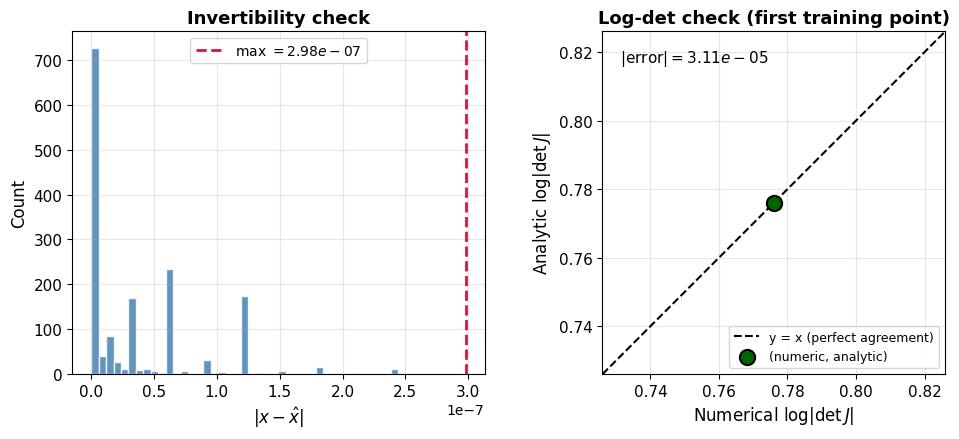

In [ ]:
# Create Figure1c: two-panel diagnostic (Q1(c))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax in axes:
    ax.tick_params(axis="both", labelsize=11)

# Left: histogram of reconstruction errors
axes[0].hist(recon_errors.reshape(-1).numpy(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(max_abs_err, color="crimson", linestyle="--", linewidth=2, label=rf"max $= {max_abs_err:.2e}$")
axes[0].set_xlabel(r"$|x - \hat{x}|$", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Invertibility check", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: agreement plot (numeric vs analytic log|det J|); point on y=x means perfect match
num_val = logdet_numeric.item()
ana_val = logdet_analytic.item()
lo = min(num_val, ana_val) - 0.05
hi = max(num_val, ana_val) + 0.05
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="y = x (perfect agreement)")
axes[1].scatter([num_val], [ana_val], s=120, zorder=5, color="darkgreen", edgecolor="black", linewidth=1.5, label="(numeric, analytic)")
axes[1].set_xlabel(r"Numerical $\log|\det J|$", fontsize=12)
axes[1].set_ylabel(r"Analytic $\log|\det J|$", fontsize=12)
axes[1].set_title("Log-det check (first training point)", fontsize=13, fontweight="bold")
axes[1].annotate(rf"$|$error$| = {logdet_abs_error:.2e}$", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=11, verticalalignment="top")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
Path("figs_my").mkdir(exist_ok=True)
fig.savefig("figs_my/Figure1c.png", dpi=300)
fig.savefig("figs/Figure1c.pdf")


## 2. Training Pipeline

### 2) (a) 

Training on the first 128 rows of the dataset using the pipeline set up in question 1.

In [45]:
#load dataset
train_df = pd.read_csv("data/moons_train.csv")
x_tiny = torch.from_numpy(train_df[["x1", "x2"]].to_numpy()).float()[:128,:]

#
flow_tiny = Flow2D(n_layers=4, hidden=64)
optimizer = torch.optim.Adam(flow_tiny.parameters(), lr = 1e-3)

#scheduler?

n_steps_tiny = 10000 
tiny_loss_history = []

flow_tiny.train()
for step in range(n_steps_tiny):
    optimizer.zero_grad()
    # calculate the average nll
    nll = -flow_tiny.log_prob(x_tiny).mean()
    nll.backward()
    optimizer.step()
    tiny_loss_history.append(nll.detach().item())

Plotting and saving results.

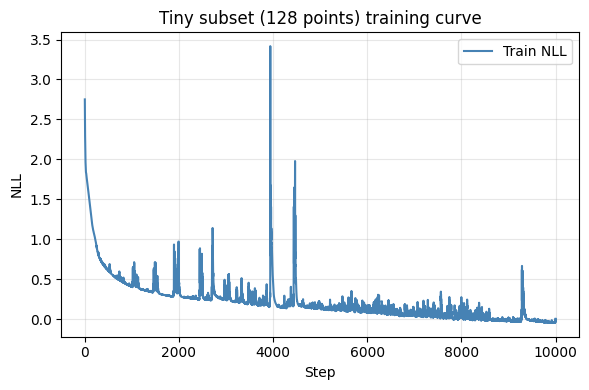

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_loss_history, color="steelblue", label="Train NLL")
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Tiny subset (128 points) training curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
Path("figs").mkdir(exist_ok=True)
Path("figs_my").mkdir(exist_ok=True)
fig.savefig("figs_my/Figure2a.png", dpi=300)
fig.savefig("figs/Figure2a.pdf")

flow_tiny.eval()
with torch.no_grad():
    final_tiny_nll = -flow_tiny.log_prob(x_tiny).mean().item()

# Load existing results (from 1(c)) and add training.tinyset_final_nll
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

results["training"]["tinyset_final_nll"] = float(final_tiny_nll)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

### 2) (b) 

Training on the full dataset, and plotting results.

In [47]:
#loading datasets
train_df = pd.read_csv("data/moons_train.csv")
val_df = pd.read_csv("data/moons_val.csv")
test_df = pd.read_csv("data/moons_test.csv")
x_train = torch.from_numpy(train_df[["x1", "x2"]].to_numpy()).float()
x_val = torch.from_numpy(val_df[["x1", "x2"]].to_numpy()).float()
x_test = torch.from_numpy(test_df[["x1", "x2"]].to_numpy()).float()

#creating flow
flow = Flow2D(n_layers=4, hidden=64)
optimizer = torch.optim.Adam(flow.parameters(), lr = 1e-3)

#adding learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

n_steps = 3000
train_loss_history = []
val_loss_history = []

# Early stopping config
patience = 300          # e.g. stop if no improvement for 300 steps
min_delta = 1e-3        # minimum improvement in NLL to count
best_val = float("inf")
bad_steps = 0
best_state_dict = None
best_step = 0

flow.train()
for step in range(n_steps):
    optimizer.zero_grad()
    # calculate the average nll
    nll = -flow.log_prob(x_train).mean()
    nll.backward()
    optimizer.step()
    scheduler.step()
    train_loss_history.append(nll.detach().item())
    
    # evaluate validation loss
    flow.eval()
    with torch.no_grad():
        val_nll = -flow.log_prob(x_val).mean().item()
    val_loss_history.append(val_nll)
    flow.train()

    # --- early stopping check ---
    if val_nll + min_delta < best_val:
        best_val = val_nll
        bad_steps = 0
        best_step = step
        best_state_dict = {k: v.cpu().clone() for k, v in flow.state_dict().items()}
    else:
        bad_steps += 1
        if bad_steps >= patience:
            print(f"Early stopping at step {step} (best val NLL at step {best_step} = {best_val:.4f})")
            break

Early stopping at step 1285 (best val NLL at step 985 = 0.4147)


Plotting loss values from training on the full dataset.

Best Training loss:  0.28863194584846497
Best Validation loss:  0.41687771677970886


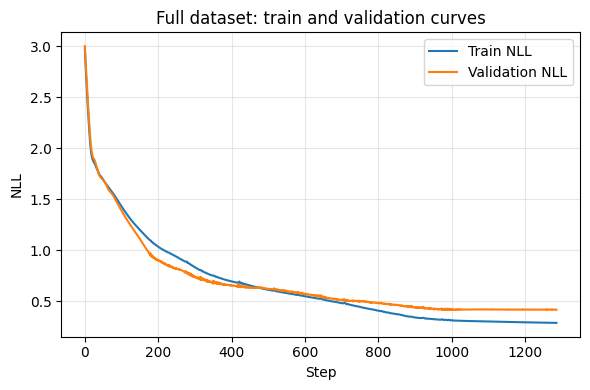

In [ ]:
print("Best Training loss: ", train_loss_history[-1])
print("Best Validation loss: ", val_loss_history[-1])

#plotting results
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_loss_history, label="Train NLL")
ax.plot(val_loss_history, label="Validation NLL")
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Full dataset: train and validation curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
Path("figs").mkdir(exist_ok=True)
Path("figs_my").mkdir(exist_ok=True)
fig.savefig("figs_my/Figure2c.png", dpi=300)
fig.savefig("figs/Figure2c.pdf")

# If early stopping was used and a best_state_dict was saved, restore it
if best_state_dict is not None:
    flow.load_state_dict(best_state_dict)

flow.eval()
with torch.no_grad():
    final_train_nll = -flow.log_prob(x_train).mean().item()
    final_val_nll = -flow.log_prob(x_val).mean().item()
    final_test_nll = -flow.log_prob(x_test).mean().item()

# Load existing results
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

results["training"]["final_train_nll"] = float(final_train_nll)
results["training"]["final_val_nll"] = float(final_val_nll)
results["training"]["final_test_nll"] = float(final_test_nll)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

### 2) (c)

Adding writeup to Results.

# NEED TO ADD TO WRITEUP AND ANSWER HERE

In [49]:
# Load existing results
results_path = Path("results.json")
with results_path.open("r") as f:
    results = json.load(f)

# Q2(c): training curves log and checkpoint
Path("logs").mkdir(exist_ok=True)
with Path("logs/training_curves.json").open("w") as f:
    json.dump({
        "tiny_loss": tiny_loss_history,
        "full_loss": train_loss_history,
        "full_val_loss": val_loss_history,
    }, f, indent=2)
Path("checkpoints").mkdir(exist_ok=True)
torch.save({
    "state_dict": flow.state_dict(),
    "config": {"n_layers": 4, "hidden": 64},
    "seed": GLOBAL_SEED,
}, "checkpoints/full_flow.pt")
results["writeup"] = (
    "Tiny subset: first 128 rows of moons_train, 10k steps, no scheduler. "
    "Full run: StepLR(step_size=3000, gamma=0.5), 3k steps, Adam 1e-3. "
    "Checkpoint stores state_dict, config (n_layers=4, hidden=64), and seed for reproducibility."
)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

## 3. Flow Surgery: A One-Parameter Family of Densities

### 3) (a) 

Implementing the Shear Map g_alpha in a ShearMap class below. The Log determinant  of the Jacobian is trivial as the Jacobian is [[1, alpha], [0, 1]], hence det = 1, and there for log |det| = 0.

In [ ]:
class ShearMap(nn.Module):
    """2D shear transform used in the coursework.

    The map is:
    - y1 = x1 + alpha * x2
    - y2 = x2

    Its Jacobian determinant is 1, so the log-determinant is identically zero.
    """

    def __init__(self, alpha):
        """Args:
            alpha: Shear parameter (alpha).
        """
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        """Forward shear.

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            y: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        y = x.clone()
        y[:, 0] = x[:, 0] + self.alpha * x[:, 1]
        return y, torch.zeros(x.size(0), device=x.device)

    def inverse(self, y):
        """Inverse shear.

        Args:
            y: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        x = y.clone()
        x[:, 0] = y[:, 0] - self.alpha * y[:, 1]
        return x, torch.zeros(y.size(0), device=y.device)

### 3) (b) 

Loading the trained model from the checkpoint.

In [ ]:
checkpoint = torch.load("checkpoints/full_flow.pt", map_location="cpu")
flow_surgery = Flow2D(
    n_layers = checkpoint["config"]["n_layers"],
    hidden= checkpoint["config"]["hidden"])
flow_surgery.load_state_dict(checkpoint["state_dict"])
flow_surgery.eval()

Flow2D(
  (layers): ModuleList(
    (0): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=2, bias=True)
        )
      )
    )
    (1): Permute2D()
    (2): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=2, bias=True)
        )
      )
    )
    (3): Permute2D()
    (4): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=2, bias=True)
        )
      )
    )
    (5): Permute2D()
    (6): AffineCoupling2D(
      (st_net): STNet(
        (net): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
    

Generating samples for each alpha value, from the trained flow and the attached ShearMap.|

In [63]:
z = torch.randn(1000,2)

alphas = [-2, -1, 0, 1, 2]

with torch.no_grad():
    x_base, _ = flow_surgery.f(z) #calculating f_0(z) for all values

#collecting samples across each alpha value
samples = {}
for alpha in alphas:
    shear = ShearMap(alpha)
    y, _ = shear(x_base)
    samples[alpha] = y.numpy()

Plot and save the created samples.

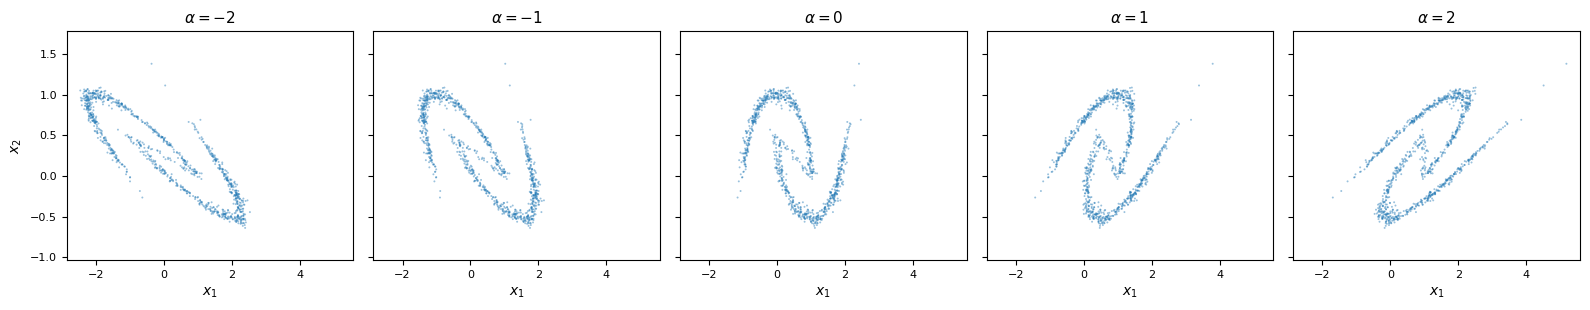

In [91]:
all_pts = np.vstack([samples[a] for a in alphas])
pad = 0.4
x_lo, x_hi = all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad
y_lo, y_hi = all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)

for ax, a in zip(axes, alphas):
    pts = samples[a]
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.45,
               color="C0", edgecolors="none", rasterized=True)
    ax.set_title(rf"$\alpha = {a}$", fontsize=11)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("$x_2$", fontsize=10)
for ax in axes:
    ax.set_xlabel("$x_1$", fontsize=10)

fig.tight_layout()
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
fig.savefig("figs_my/Figure3b.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. FLOP Counting Function

### 4) (a) 

Calculating the number of FLOPs the flow uses. The variables that contribute to the complexity of this calculation are given below.

- D = dim
- H = hidden
- K = n_layers
- B = batch_size

The count covers one evaluation of log p(x) for a batch of B examples through K coupling layers. It includes the inverse pass, the log-determinant computation at each layer, and the base-density evaluation.

Each coupling layer runs an MLP: Linear(D/2 → H) → ReLU → Linear(H → D). The first linear layer costs H·D FLOPs per example (D/2 multiplications and D/2 additions per neuron, across H neurons). ReLU adds H FLOPs. The second linear layer costs 2·D·H FLOPs. Tanh is applied to the D/2 scale outputs at 10 FLOPs each. The inverse transform subtracts t (D/2 ops), exponentiates s (10·D/2 ops), and divides (D/2 ops). The log-determinant negates and sums D/2 values, costing D − 1 FLOPs.

Permutation layers swap indices with no arithmetic. The base density costs a flat 20 FLOPs per example, as given in the specification. Accumulating log-determinants across K layers and combining with the base log-prob adds K additions per example.

Assumptions: only the inverse pass is counted. Permutations, tensor slicing, concatenation, and Python overhead carry zero cost. The 20-FLOP base-density rate bundles all internal arithmetic (log(2π), squaring, summation, scaling). Each addition, multiplication, and division costs 1 FLOP; each tanh and exp costs 10.

**Assumptions**
- Only the inverse pass is counted (since `log p(x)` uses `f_inv`, not the forward/sampling map).
- Permutation layers cost 0 FLOPs (they are pure index swaps, no arithmetic).
- Linear(in, out) is counted as `2 * in * out` FLOPs: in multiplications and in adds (including bias) per output neuron.
- Base density evaluation is 20 FLOPs per example as specified in the cost table (this bundles the `log(2π)`, squaring, summing, and scaling into the flat rate).
- Python/indexing overhead, tensor slicing, and concatenation are ignored (as instructed).
- The function handles general even `dim`, but the submitted model uses `dim=2`.



### 4) (b) 

Implementing this calculation in code.

In [ ]:
def count_flops(*, dim, n_layers, hidden, batch_size):
    """Analytically count FLOPs for evaluating log p(x).

    This follows the coursework's accounting assumptions (e.g. fixed costs for `tanh`
    and base density evaluation) and is intended for comparing configurations rather
    than exact hardware FLOP counts.

    Args:
        dim: Data dimensionality (D).
        n_layers: Number of coupling layers (K).
        hidden: Hidden width (H) of the coupling MLP.
        batch_size: Batch size (B).

    Returns:
        Total FLOPs for a single batch (integer).
    """
    D = dim
    H = hidden
    K = n_layers
    B = batch_size

    # --- Per coupling layer, per example ---
    # MLP: Linear(D/2 -> H) -> ReLU -> Linear(H -> D), then split into s, t
    linear1 = H * D              # Linear(D/2 -> H): H neurons, each D/2 muls + D/2 adds
    relu = H                     # ReLU on H activations, 1 FLOP each
    linear2 = 2 * D * H          # Linear(H -> D): D neurons, each H muls + H adds
    tanh_s = 10 * (D // 2)       # tanh on s (D/2 values), 10 FLOPs each

    # Inverse coupling transform on D/2 transformed dims:
    #   subtract t: D/2,  exp(s): 10*(D/2),  divide: D/2
    inv_transform = (D // 2) + 10 * (D // 2) + (D // 2)

    # Log-det: negate D/2 values and sum them: D/2 + (D/2 - 1) = D - 1
    log_det = D - 1

    per_layer = linear1 + relu + linear2 + tanh_s + inv_transform + log_det

    # --- Across all layers ---
    coupling_total = K * per_layer

    # Accumulating log-det across layers: K-1 additions for running sum
    # Plus 1 addition to combine with base log-prob
    log_det_accum = K

    # Base density: 20 FLOPs per example (given in spec)
    base_density = 20

    per_example = coupling_total + log_det_accum + base_density
    return B * per_example

Verifying this function.

In [93]:
flops = count_flops(dim=2, n_layers=4, hidden=64, batch_size=1)
print(f"FLOPs for single example: {flops}")
flops_batch = count_flops(dim=2, n_layers=4, hidden=64, batch_size=100)
print(f"FLOPs for batch of 100:   {flops_batch}")

FLOPs for single example: 1908
FLOPs for batch of 100:   190800
